# Laboratorio 5 — Modelos de lenguaje

**Milton Beltrán** · Natural Language Processing

**Corpus:** *El ingenioso hidalgo don Quijote de la Mancha*, de Miguel de Cervantes
(Kaggle: [`manuelmaaf97/quijote`](https://www.kaggle.com/datasets/manuelmaaf97/quijote)).

A diferencia de los laboratorios #1 a #4, este no usa el corpus de noticias en español:
cambia de corpus y **de objetivo**. Ya no se clasifica un documento en una categoría, sino
que se predice la siguiente palabra de una secuencia. Eso invierte el pipeline de
normalización que se venía usando:

| Labs #1–#4 (clasificación) | Lab #5 (modelado de lenguaje) |
|---|---|
| Se eliminan las *stopwords* | Se conservan: son las palabras que un LM más predice |
| Stemming con `SnowballStemmer` | Ninguno: se predice la palabra de superficie |
| Bolsa de palabras, el orden no importa | El orden **es** el dato |
| Unidad de análisis: el documento | Unidad de análisis: la **oración**, con `<s>` y `</s>` |
| Partición estratificada por etiqueta | Partición aleatoria 80/10/10 (no hay etiquetas) |

Los modelos n-grama se implementan **desde cero** con `defaultdict`, según exige el
enunciado: no se usa `nltk.lm` ni `kenlm`. NLTK interviene únicamente para segmentar en
oraciones y tokenizar.

## 0. Preparación del entorno y carga del corpus

Descarga del corpus, lectura del texto crudo y recorte del aparato editorial de Project
Gutenberg. Al terminar esta sección hay una sola variable de interés, `texto`: el cuerpo
del libro como una cadena, todavía sin segmentar.

In [37]:
# --- 0.1 Librerías ---
# La variable de NLTK va antes del import: su hook de seguridad bloquea `regex` cuando
# el .venv vive dentro del directorio de trabajo.
import os

os.environ["NLTK_DISABLE_IMPORT_SECURITY"] = "1"

# --- Librerías estándar de Python ---
import math
import random
import re
from collections import Counter, defaultdict
from pathlib import Path

# --- Gráficos ---
import matplotlib.pyplot as plt

# --- NLP ---
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

# --- Descarga del corpus ---
import kagglehub

RANDOM_STATE = 42
random.seed(RANDOM_STATE)

# Tokens de frontera de oración.
BOS, EOS = "<s>", "</s>"

print("Librerías cargadas · NLTK", nltk.__version__, "· kagglehub", kagglehub.__version__)

Librerías cargadas · NLTK 3.10.1 · kagglehub 1.0.2


In [38]:
# --- 0.2 Recursos de NLTK ---
# `punkt_tab` es el modelo del sentenizador, entrenado por idioma.
for recurso in ["punkt", "punkt_tab"]:
    nltk.download(recurso, quiet=True)

print("Recursos de NLTK listos.")

Recursos de NLTK listos.


In [39]:
# --- 0.3 Descarga del corpus ---
# Dataset público: no pide credenciales y queda cacheado en ~/.cache/kagglehub, así que
# solo baja la primera vez. No se guarda copia en el repositorio (decisión D-06).
ruta_dataset = Path(kagglehub.dataset_download("manuelmaaf97/quijote"))
RUTA_TXT = ruta_dataset / "don-quijote.txt"

print("Directorio del dataset:", ruta_dataset)
print("Archivo:", RUTA_TXT.name, f"({RUTA_TXT.stat().st_size / 1024**2:.1f} MB)")

Directorio del dataset: /Users/milton/.cache/kagglehub/datasets/manuelmaaf97/quijote/versions/1
Archivo: don-quijote.txt (2.1 MB)


In [40]:
# --- 0.4 Lectura del texto crudo ---
# El archivo trae BOM: con "utf-8" a secas el carácter \ufeff queda pegado al primer token.
texto_crudo = RUTA_TXT.read_text(encoding="utf-8-sig")

print(f"Caracteres: {len(texto_crudo):,}")
print(f"Líneas:     {texto_crudo.count(chr(10)):,}")
print("¿Sobrevive el BOM?:", texto_crudo.startswith("\ufeff"))
print()
print("Primeros 200 caracteres:")
print(texto_crudo[:200])

Caracteres: 2,117,497
Líneas:     37,861
¿Sobrevive el BOM?: False

Primeros 200 caracteres:
The Project Gutenberg EBook of Don Quijote, by Miguel de Cervantes Saavedra

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give 


In [41]:
# --- 0.5 Recorte del aparato editorial de Project Gutenberg ---
# El archivo es el ebook #2000 de Gutenberg: cabecera y licencia en inglés alrededor del
# libro. Se corta por los marcadores y no por número de línea (decisión D-07).
MARCA_INICIO = "*** START OF THIS PROJECT GUTENBERG EBOOK"
MARCA_FIN = "*** END OF THIS PROJECT GUTENBERG EBOOK"

ini = texto_crudo.index(MARCA_INICIO)
ini = texto_crudo.index("\n", ini) + 1  # saltar la línea del marcador
fin = texto_crudo.index(MARCA_FIN)

texto_sin_licencia = texto_crudo[ini:fin].strip()

descartado = len(texto_crudo) - len(texto_sin_licencia)
print(f"Antes del recorte:   {len(texto_crudo):>9,} caracteres")
print(f"Después del recorte: {len(texto_sin_licencia):>9,} caracteres")
print(f"Descartado:          {descartado:>9,} caracteres ({descartado / len(texto_crudo):.1%})")

Antes del recorte:   2,117,497 caracteres
Después del recorte: 2,098,163 caracteres
Descartado:             19,334 caracteres (0.9%)


In [42]:
# --- 0.6 Comprobación: ¿qué queda del aparato editorial? ---
# Los marcadores no bastan: hay líneas en inglés dentro de la región que delimitan.
restos = [linea.strip() for linea in texto_sin_licencia.split("\n") if "Gutenberg" in linea]

print(f"Líneas con 'Gutenberg' que sobreviven al recorte: {len(restos)}\n")
for linea in restos:
    print("  ·", linea)

Líneas con 'Gutenberg' que sobreviven al recorte: 2

  · Produced by an anonymous Project Gutenberg volunteer. Text
  · End of Project Gutenberg's Don Quijote, by Miguel de Cervantes Saavedra


## 1. Preparación del corpus para modelado de secuencias

Pendiente. Pasos, en orden:

1. Descartar los restos editoriales detectados en 0.6 y decidir qué hacer con los **126
   encabezados de capítulo** y con los preliminares —TASA, privilegio real, versos
   dedicatorios— que no son prosa narrativa (decisión D-10, abierta en la bitácora).
2. **Reconstruir los párrafos.** El texto trae *wrap* duro a ~76 columnas: el salto de
   línea es tipográfico, no sintáctico, y una oración cruza varias líneas físicas
   (hallazgo H-03). Los párrafos están separados por líneas en blanco. Sentenizar sin
   reconstruirlos partiría casi todas las oraciones a la mitad.
3. Segmentar cada párrafo en oraciones con `sent_tokenize(..., language="spanish")`.
4. Tokenizar cada oración con `word_tokenize(..., language="spanish")`. **Sin** quitar
   *stopwords* y **sin** stemming.
5. Envolver cada oración entre `BOS` y `EOS`.
6. Partir las oraciones en 80 % entrenamiento / 10 % validación / 10 % prueba de forma
   aleatoria, con `RANDOM_STATE` fijo.
7. Reportar el tamaño del vocabulario de entrenamiento y la proporción de palabras de
   prueba que no aparecen en él (OOV).
8. Explicar la relación entre las palabras nunca vistas y la dispersión de datos.

In [43]:
# --- 0.7 Recorte fino: de la portadilla a la palabra "Fin" ---
# Se corta por anclas del propio libro. Para el cierre, `rindex` sobre la línea exacta
# "\nFin\n": un `index` sobre "Fin" atraparía "Finalmente" o el "Finis" de 1605.
PORTADILLA = "El ingenioso hidalgo don Quijote de la Mancha"

texto = texto_sin_licencia[
    texto_sin_licencia.index(PORTADILLA) : texto_sin_licencia.rindex("\nFin\n")
].strip()

print(f"Cuerpo del libro: {len(texto):,} caracteres")
print("Restos de Project Gutenberg:",
      sum(1 for linea in texto.split("\n") if "Gutenberg" in linea))
print()
print("Empieza:", repr(texto[:70]))
print("Termina:", repr(texto[-70:]))

Cuerpo del libro: 2,097,945 caracteres
Restos de Project Gutenberg: 0

Empieza: 'El ingenioso hidalgo don Quijote de la Mancha\n\n\nTASA\n\nYo, Juan Gallo d'
Termina: 'ote, van ya tropezando, y han de caer del todo, sin duda alguna. Vale.'


## 1. Preparación del corpus para modelado de secuencias

De la cadena `texto` a una lista de oraciones tokenizadas, particionadas en 80/10/10, con
el vocabulario de entrenamiento y la tasa de palabras nunca vistas.

In [44]:
# --- 1.1 Reconstrucción de los párrafos ---
# El texto trae wrap duro a ~76 columnas: una oración cruza varias líneas físicas, así que
# hay que rearmar el párrafo antes de sentenizar. Se unen con espacio, no con "".
bloques = re.split(r"\n\s*\n", texto)
parrafos = [re.sub(r"\s+", " ", " ".join(bloque.split("\n")).strip()) for bloque in bloques]
parrafos = [p for p in parrafos if p]

print(f"Párrafos reconstruidos: {len(parrafos):,}")
print(f"Longitud media: {sum(len(p.split()) for p in parrafos) / len(parrafos):.1f} palabras")
print()
ejemplo = next(p for p in parrafos if p.startswith("En un lugar de la Mancha"))
print("El párrafo inicial del capítulo I, ya en una sola línea:")
print(ejemplo[:280], "...")

Párrafos reconstruidos: 5,191
Longitud media: 73.4 palabras

El párrafo inicial del capítulo I, ya en una sola línea:
En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua, rocín flaco y galgo corredor. Una olla de algo más vaca que carnero, salpicón las más noches, duelos y quebrantos los sábados, lante ...


In [45]:
# --- 1.2 Encabezados estructurales (decisión D-10) ---
# Se eliminan los 126 encabezados de capítulo y las 5 divisiones de parte. No por volumen,
# sino porque Punkt los parte en dos oraciones malformadas que se llevan sus propios
# <s> y </s>. Los preliminares (TASA, prólogo, versos) sí se conservan.
ENCABEZADO = re.compile(r"^(Cap[íi]tulo\b|(Primera|Segunda|Tercera|Cuarta) parte del ingenioso)")

encabezados = [p for p in parrafos if ENCABEZADO.match(p)]
parrafos_prosa = [p for p in parrafos if not ENCABEZADO.match(p)]

print(f"Encabezados eliminados: {len(encabezados)}")
print(f"Párrafos restantes:     {len(parrafos_prosa):,}")
print()
print("Lo que Punkt haría con un encabezado si se dejara:")
for oracion in sent_tokenize(next(p for p in encabezados if p.startswith("Capítulo")),
                             language="spanish"):
    print("   ·", oracion)

Encabezados eliminados: 131
Párrafos restantes:     5,060

Lo que Punkt haría con un encabezado si se dejara:
   · Capítulo primero.
   · Que trata de la condición y ejercicio del famoso hidalgo don Quijote de la Mancha


In [46]:
# --- 1.3 Dos arreglos de tokenización propios del español ---
# `word_tokenize` está pensado para el inglés y deja pegadas la raya de diálogo ("-porque")
# y la apertura de interrogación ("¿cómo"). Son 1,299 tipos espurios en este corpus.
# La raya solo se separa si no tiene letra a ambos lados, para no partir "físico-químico".
LETRA = r"A-Za-zÁÉÍÓÚÜÑáéíóúüñ"
RAYA = re.compile(rf"(?<![{LETRA}])-|-(?![{LETRA}])")
APERTURA = re.compile(r"([¿¡])")


def separa_signos(parrafo):
    """Despega la raya de diálogo y los signos de apertura del token que los sigue."""
    return APERTURA.sub(r" \1 ", RAYA.sub(" - ", parrafo))


demo = "-Porque, ¿cómo queréis vos que no me tenga confuso?"
print("Sin arreglo:", word_tokenize(demo, language="spanish"))
print("Con arreglo:", word_tokenize(separa_signos(demo), language="spanish"))

Sin arreglo: ['-Porque', ',', '¿cómo', 'queréis', 'vos', 'que', 'no', 'me', 'tenga', 'confuso', '?']
Con arreglo: ['-', 'Porque', ',', '¿', 'cómo', 'queréis', 'vos', 'que', 'no', 'me', 'tenga', 'confuso', '?']


In [47]:
# --- 1.4 Segmentación en oraciones y tokenización ---
# Al revés que en los labs #1-#4: sin quitar stopwords y sin stemming, porque el modelo
# predice la palabra que de verdad sigue. Sí se pasa a minúsculas (D-13) y la puntuación
# se conserva como token (D-14). Los signos se separan antes de sentenizar.
oraciones = []
for parrafo in parrafos_prosa:
    for oracion in sent_tokenize(separa_signos(parrafo), language="spanish"):
        tokens = [t.lower() for t in word_tokenize(oracion, language="spanish")]
        if tokens:
            oraciones.append(tokens)

n_tokens = sum(len(s) for s in oraciones)
print(f"Oraciones: {len(oraciones):,}")
print(f"Tokens:    {n_tokens:,}")
print(f"Longitud media: {n_tokens / len(oraciones):.1f} tokens · máxima: {max(map(len, oraciones)):,}")
print()
print("Primera oración del libro, tokenizada:")
print(next(s for s in oraciones if "lugar" in s and "mancha" in s)[:24])

Oraciones: 10,572
Tokens:    444,836
Longitud media: 42.1 tokens · máxima: 555

Primera oración del libro, tokenizada:
['en', 'un', 'lugar', 'de', 'la', 'mancha', ',', 'de', 'cuyo', 'nombre', 'no', 'quiero', 'acordarme', ',', 'no', 'ha', 'mucho', 'tiempo', 'que', 'vivía', 'un', 'hidalgo', 'de', 'los']


In [48]:
# --- 1.5 Tokens de frontera <s> y </s> ---
# <s> da contexto para condicionar la primera palabra; </s> es lo que hace que las
# probabilidades de todas las oraciones posibles sumen 1.
oraciones = [[BOS] + tokens + [EOS] for tokens in oraciones]

print("Ejemplo:", oraciones[0][:12], "...", oraciones[0][-3:])
print(f"Tokens totales con fronteras: {sum(len(s) for s in oraciones):,}")

Ejemplo: ['<s>', 'el', 'ingenioso', 'hidalgo', 'don', 'quijote', 'de', 'la', 'mancha', '</s>'] ... ['la', 'mancha', '</s>']
Tokens totales con fronteras: 465,980


In [49]:
# --- 1.6 Partición 80 / 10 / 10 ---
# Aleatoria y no estratificada: aquí no hay etiquetas que balancear. La unidad que se
# reparte es la oración, que se evalúa de forma independiente desde <s>.
indices = list(range(len(oraciones)))
random.shuffle(indices)

corte_train = int(0.8 * len(indices))
corte_val = corte_train + int(0.1 * len(indices))

train = [oraciones[i] for i in indices[:corte_train]]
val = [oraciones[i] for i in indices[corte_train:corte_val]]
test = [oraciones[i] for i in indices[corte_val:]]

for nombre, particion in [("Entrenamiento", train), ("Validación", val), ("Prueba", test)]:
    n_tok = sum(len(s) for s in particion)
    print(f"{nombre:<14} {len(particion):>6,} oraciones ({len(particion)/len(oraciones):>5.1%})"
          f"   {n_tok:>8,} tokens")

Entrenamiento   8,457 oraciones (80.0%)    373,242 tokens
Validación      1,057 oraciones (10.0%)     45,780 tokens
Prueba          1,058 oraciones (10.0%)     46,958 tokens


In [50]:
# --- 1.7 Vocabulario de entrenamiento y palabras nunca vistas (OOV) ---
# El vocabulario se define solo con train; mirar val o test sería fuga.
tokens_train = [t for s in train for t in s]
conteo_train = Counter(tokens_train)
vocabulario = set(conteo_train)

hapax = sum(1 for t, n in conteo_train.items() if n == 1)
print(f"Vocabulario de entrenamiento: {len(vocabulario):,} tipos")
print(f"Hapax legomena (frecuencia 1): {hapax:,} = {hapax/len(vocabulario):.1%} del vocabulario")
print()

# Por token: de cada 100 palabras leídas, ¿cuántas no conozco?
# Por tipo: de cada 100 palabras distintas, ¿cuántas no conozco? Dan cifras muy separadas.
for nombre, particion in [("Validación", val), ("Prueba", test)]:
    tokens = [t for s in particion for t in s]
    tipos = set(tokens)
    oov_token = sum(1 for t in tokens if t not in vocabulario)
    oov_tipo = len(tipos - vocabulario)
    print(f"{nombre}:")
    print(f"   OOV por token: {oov_token:>6,} / {len(tokens):>7,} = {oov_token/len(tokens):.2%}")
    print(f"   OOV por tipo : {oov_tipo:>6,} / {len(tipos):>7,} = {oov_tipo/len(tipos):.2%}")

con_oov = sum(1 for s in test if any(t not in vocabulario for t in s))
print()
print(f"Oraciones de prueba con al menos un OOV: {con_oov:,}/{len(test):,} = {con_oov/len(test):.1%}")

Vocabulario de entrenamiento: 20,497 tipos
Hapax legomena (frecuencia 1): 10,277 = 50.1% del vocabulario

Validación:
   OOV por token:  1,243 /  45,780 = 2.72%
   OOV por tipo :  1,200 /   6,190 = 19.39%
Prueba:
   OOV por token:  1,326 /  46,958 = 2.82%
   OOV por tipo :  1,261 /   6,435 = 19.60%

Oraciones de prueba con al menos un OOV: 564/1,058 = 53.3%


In [51]:
# --- 1.8 La dispersión, medida sobre n-gramas ---
# El OOV mide dispersión a nivel de palabra, pero el modelo necesita haber visto la
# secuencia, no la palabra. Esta tabla es la que justifica las secciones 3 y 4.
def n_gramas(particion, n):
    return [tuple(s[i:i+n]) for s in particion for i in range(len(s) - n + 1)]


print(f"{'n':<4}{'no vistos en train':>22}{'':4}{'porcentaje':>12}")
for n in (1, 2, 3):
    vistos = set(n_gramas(train, n))
    gramas_val = n_gramas(val, n)
    nuevos = sum(1 for g in gramas_val if g not in vistos)
    print(f"{n:<4}{nuevos:>10,} / {len(gramas_val):<9,}{'':4}{nuevos/len(gramas_val):>11.1%}")

n       no vistos en train      porcentaje
1        1,243 / 45,780              2.7%
2       10,969 / 44,723             24.5%
3       26,287 / 43,666             60.2%


### 1.9 Resultados y discusión

El corpus quedó en 10,572 oraciones repartidas en **8,457 / 1,057 / 1,058**, con 42.1 tokens
de media. El vocabulario de entrenamiento tiene 20,497 palabras distintas sobre 373,242
tokens, y en prueba el **2.82 %** de las palabras que el modelo lee no están en él. Medida
sobre palabras distintas, la cifra sube a **19.60 %**.

Las dos responden a preguntas diferentes y por eso se separan tanto: de cada cien palabras
leídas casi tres son desconocidas, pero de cada cien palabras *distintas* lo son veinte. Lo
desconocido es casi todo raro. El dato que lo explica es que 10,277 de las 20,497 palabras
del vocabulario aparecen una sola vez en entrenamiento, el **50.1 %**. Aun así, el **53.3 %**
de las oraciones de prueba tiene al menos una palabra que el modelo nunca vio.

#### ¿Qué relación tiene esto con la dispersión de datos?

Las palabras nunca vistas son la versión leve del problema. Con 20 mil palabras hay 4 × 10⁸
bigramas posibles y 8 × 10¹² trigramas contra 373 mil tokens de entrenamiento: la tabla de
conteos está casi vacía, y no por culpa del corpus, sino porque ninguno de tamaño razonable
la llenaría. Y un modelo n-grama no necesita conocer la palabra sino la secuencia, así que
la dispersión que le pega es bastante peor:

| n | No vistos en entrenamiento | % |
|---|---|---|
| 1 (palabras) | 1,243 / 45,780 | 2.7 % |
| 2 (bigramas) | 10,969 / 44,723 | 24.5 % |
| 3 (trigramas) | 26,287 / 43,666 | 60.2 % |

Seis de cada diez trigramas de validación no aparecen nunca, aunque sus tres palabras sí
sean conocidas. Con máxima verosimilitud un solo cero anula la oración entera, porque la
regla de la cadena multiplica: el trigrama le daría probabilidad cero a casi cualquier
oración nueva y perplejidad infinita. De ahí que la sección 3 tenga que suavizar.

Esa misma tabla es el compromiso entre contexto y dispersión que se mide en la sección 4:
al subir n el modelo gana contexto pero pierde los datos para estimarlo.

## 2. Construcción de modelos n-grama

Unigrama, bigrama y trigrama estimados por conteo, implementados desde cero con
`defaultdict`. Sin `nltk.lm` ni `kenlm`, como pide el enunciado.

In [52]:
# --- 2.1 Modelo n-grama por conteos ---
# `conteo` guarda el n-grama completo y `contexto` sus n-1 primeras palabras, que es el
# denominador de la estimación. El parámetro k queda listo para la sección 3: k=0 es
# máxima verosimilitud, sin suavizar.
class ModeloNGrama:

    def __init__(self, n):
        self.n = n
        self.conteo = defaultdict(int)
        self.contexto = defaultdict(int)
        self.vocabulario = set()

    def _con_padding(self, oracion):
        """La oración trae un <s>; un modelo de orden n necesita n-1 al inicio.

        Con n=1 se descarta el <s>: el unigrama no lo predice ni condiciona en él. Así los
        tres modelos predicen exactamente los mismos tokens y sus perplejidades se pueden
        comparar en la sección 4.
        """
        if self.n == 1:
            return oracion[1:]
        return [BOS] * (self.n - 2) + oracion

    def entrenar(self, oraciones):
        for oracion in oraciones:
            self.vocabulario.update(t for t in oracion if t != BOS)
            tokens = self._con_padding(oracion)
            for i in range(len(tokens) - self.n + 1):
                grama = tuple(tokens[i:i + self.n])
                self.conteo[grama] += 1
                self.contexto[grama[:-1]] += 1
        return self

    def prob(self, contexto, palabra, k=0.0):
        # Se lee con .get y no con [] : un defaultdict inserta la clave al consultarla, y
        # evaluar el corpus entero llenaría las tablas de n-gramas con ceros.
        contexto = tuple(contexto)
        c_grama = self.conteo.get(contexto + (palabra,), 0)
        c_contexto = self.contexto.get(contexto, 0)
        if k == 0.0:
            return c_grama / c_contexto if c_contexto else 0.0
        return (c_grama + k) / (c_contexto + k * len(self.vocabulario))

    def log_prob_oracion(self, oracion, k=0.0):
        """Regla de la cadena en log-espacio. Devuelve -inf si algún n-grama tiene cuenta 0."""
        tokens = self._con_padding(oracion)
        m = self.n - 1
        total = 0.0
        for i in range(m, len(tokens)):
            p = self.prob(tokens[i - m:i], tokens[i], k)
            if p == 0.0:
                return float("-inf")
            total += math.log(p)
        return total

In [53]:
# --- 2.2 Entrenamiento de los tres modelos ---
modelos = {n: ModeloNGrama(n).entrenar(train) for n in (1, 2, 3)}

print(f"{'n':<4}{'n-gramas distintos':>20}{'contextos distintos':>22}")
for n, modelo in modelos.items():
    print(f"{n:<4}{len(modelo.conteo):>20,}{len(modelo.contexto):>22,}")

print(f"\nVocabulario (sin <s>): {len(modelos[1].vocabulario):,}")
print(f"Tokens de entrenamiento predichos por el unigrama: {modelos[1].contexto[()]:,}")

n     n-gramas distintos   contextos distintos
1                 20,496                     1
2                124,041                20,496
3                248,584               123,996

Vocabulario (sin <s>): 20,496
Tokens de entrenamiento predichos por el unigrama: 364,785


In [54]:
# --- 2.3 Qué aporta el contexto ---
# La misma palabra estimada con 0, 1 y 2 palabras de historia.
for contexto in ([], ["don"], ["respondió", "don"]):
    modelo = modelos[len(contexto) + 1]
    grama = tuple(contexto) + ("quijote",)
    print(f"P(quijote | {' '.join(contexto) or '—':<13}) = "
          f"{modelo.conteo[grama]:>6,} / {modelo.contexto[tuple(contexto)]:>7,} = "
          f"{modelo.prob(contexto, 'quijote'):.4f}")

P(quijote | —            ) =  1,703 / 364,785 = 0.0047
P(quijote | don          ) =  1,697 /   2,069 = 0.8202
P(quijote | respondió don) =    212 /     223 = 0.9507


In [55]:
# --- 2.4 Probabilidad de una oración de validación ---
# Regla de la cadena con la aproximación de Markov, calculada en log-espacio.
ejemplo = next(o for o in val
               if " ".join(o[1:-1]).startswith("- y yo lo digo también"))

print(" ".join(ejemplo))
print(f"{len(ejemplo) - 1} tokens predichos por cada modelo\n")

print(f"{'Modelo':<12}{'log P':>12}{'P':>16}")
for n, modelo in modelos.items():
    log_p = modelo.log_prob_oracion(ejemplo)
    nombre = {1: "Unigrama", 2: "Bigrama", 3: "Trigrama"}[n]
    if log_p == float("-inf"):
        print(f"{nombre:<12}{'-inf':>12}{'0':>16}")
    else:
        print(f"{nombre:<12}{log_p:>12.3f}{math.exp(log_p):>16.4e}")

<s> - y yo lo digo también - respondió don quijote - . </s>
13 tokens predichos por cada modelo

Modelo             log P               P
Unigrama         -65.179      4.9340e-29
Bigrama          -38.270      2.3962e-17
Trigrama            -inf               0


In [56]:
# --- 2.5 Dónde exactamente se rompe el trigrama ---
# El bigrama recorre la oración entera; el trigrama se cae en un solo n-grama.
print("Bigrama, factor a factor:")
for i in range(1, len(ejemplo)):
    anterior, actual = ejemplo[i - 1], ejemplo[i]
    print(f"   P({actual:<10} | {anterior:<10}) = {modelos[2].conteo[(anterior, actual)]:>5,}"
          f" / {modelos[2].contexto[(anterior,)]:>6,} = {modelos[2].prob([anterior], actual):.5f}")

print("\nTrigramas de la oración y su cuenta en entrenamiento:")
tokens = modelos[3]._con_padding(ejemplo)
for i in range(2, len(tokens)):
    grama = tuple(tokens[i - 2:i + 1])
    cuenta = modelos[3].conteo[grama]
    marca = "  <-- cuenta 0" if cuenta == 0 else ""
    print(f"   {' '.join(grama):<38} c = {cuenta:>4,}{marca}")

Bigrama, factor a factor:
   P(-          | <s>       ) = 2,611 /  8,457 = 0.30874
   P(y          | -         ) =    67 /  5,679 = 0.01180
   P(yo         | y         ) =   112 / 14,508 = 0.00772
   P(lo         | yo        ) =    28 /  1,682 = 0.01665
   P(digo       | lo        ) =     7 /  2,751 = 0.00254
   P(también    | digo      ) =     1 /    266 = 0.00376
   P(-          | también   ) =     6 /    190 = 0.03158
   P(respondió  | -         ) =   659 /  5,679 = 0.11604
   P(don        | respondió ) =   223 /    857 = 0.26021
   P(quijote    | don       ) = 1,697 /  2,069 = 0.82020
   P(-          | quijote   ) =   443 /  1,703 = 0.26013
   P(.          | -         ) =   150 /  5,679 = 0.02641
   P(</s>       | .         ) = 6,271 /  6,297 = 0.99587

Trigramas de la oración y su cuenta en entrenamiento:
   <s> <s> -                              c = 2,611
   <s> - y                                c =   59
   - y yo                                 c =    4
   y yo lo              

In [57]:
# --- 2.6 Por qué el cálculo va en logaritmos ---
# Multiplicar cientos de probabilidades menores que 1 desborda el punto flotante por abajo.
larga = max(train, key=len)

producto = 1.0
for token in modelos[1]._con_padding(larga):
    producto *= modelos[1].prob([], token)

print(f"Oración más larga de entrenamiento: {len(larga) - 2:,} palabras")
print(f"   log P (suma de logaritmos) = {modelos[1].log_prob_oracion(larga):,.1f}")
print(f"   producto directo           = {producto}")
print(f"   menor float positivo       = {5e-324}")

Oración más larga de entrenamiento: 329 palabras
   log P (suma de logaritmos) = -2,050.5
   producto directo           = 0.0
   menor float positivo       = 5e-324


### 2.7 Resultados y discusión

El unigrama guarda 20,496 entradas, el bigrama 124,041 y el trigrama 248,584, todas
estimadas con los mismos 373,242 tokens: cada entrada del trigrama se apoya en la mitad de
evidencia que una del bigrama.

Lo que aporta el contexto se ve en una sola palabra. `quijote` ocupa el 0.47 % del corpus;
después de `don` sube a 0.8202, y después de `respondió don` a 0.9507. Para la oración de
validación `- y yo lo digo también - respondió don quijote - .`, con 13 tokens predichos:

| Modelo | log P | P |
|---|---|---|
| Unigrama | −65.179 | 4.93 × 10⁻²⁹ |
| Bigrama | −38.270 | 2.40 × 10⁻¹⁷ |
| Trigrama | −inf | 0 |

El bigrama le da doce órdenes de magnitud más probabilidad que el unigrama. El trigrama no
da un número peor: no da número. Y la culpa es de **un solo** trigrama de los trece, `lo
digo también`; los otros doce sí están, y `respondió don quijote` aparece 212 veces sobre
223. Un cero anula el producto entero, que es exactamente el problema de la sección 3.

#### ¿Cómo se pasa de la regla de la cadena a los modelos n-grama?

La regla de la cadena es exacta y no supone nada: P(w₁…wₙ) = ∏ P(wᵢ | w₁…wᵢ₋₁). El problema
no es la fórmula sino estimar sus factores. Para calcular P(quijote | - y yo lo digo también
- respondió don) por conteo habría que haber visto ese prefijo exacto varias veces, y
aparece cero. Ya con trigramas falta el 60.2 % de los de validación; con contextos de diez
palabras faltaría prácticamente el 100 %. La regla es correcta e inservible a la vez: pide
algo que no se puede contar.

El supuesto de Markov dice que basta con las n−1 palabras anteriores,
P(wᵢ | w₁…wᵢ₋₁) ≈ P(wᵢ | wᵢ₋ₙ₊₁…wᵢ₋₁). Es falso como descripción del lenguaje —en una
oración larga de Cervantes el sujeto condiciona un verbo que llega treinta palabras
después— pero vuelve contable lo que no lo era: en vez del prefijo entero, el bigrama usa
las 2,069 apariciones de `don` y estima P(quijote | don) = 0.8202. Se gana poder estimar y
se paga olvidando; elegir n es elegir cuánta memoria conservar.

#### Por qué el cálculo va en logaritmos

La oración más larga de entrenamiento tiene 329 palabras. Su log P bajo el unigrama es
−2,050.5, pero el producto directo de sus factores devuelve **0.0**, porque el menor float
positivo representable es 5 × 10⁻³²⁴. Sin logaritmos el modelo declararía imposible una
oración de su propio corpus de entrenamiento. Es el mismo caso del Lab #3 con Naive Bayes.

## 3. Suavizado

Laplace (add-1) y add-k sobre el modelo de bigramas. La clase de la sección 2 ya recibe `k`,
así que aquí no hay código nuevo de modelo: solo se compara qué pasa al moverlo.

In [58]:
# --- 3.1 El costo del suavizado sobre una oración que no lo necesitaba ---
# Misma oración de la celda 2.4: todos sus bigramas están en entrenamiento.
VALORES_K = [1.0, 0.1, 0.01, 0.001]  # k=1 es Laplace
bigrama = modelos[2]

print(" ".join(ejemplo), "\n")
print(f"{'k':<10}{'log P':>12}{'P':>14}")
print(f"{'0 (sin)':<10}{bigrama.log_prob_oracion(ejemplo):>12.3f}"
      f"{math.exp(bigrama.log_prob_oracion(ejemplo)):>14.3e}")
for k in VALORES_K:
    log_p = bigrama.log_prob_oracion(ejemplo, k=k)
    print(f"{k:<10}{log_p:>12.3f}{math.exp(log_p):>14.3e}")

<s> - y yo lo digo también - respondió don quijote - . </s> 

k                log P             P
0 (sin)        -38.270     2.396e-17
1.0            -67.291     5.966e-30
0.1            -48.376     9.783e-22
0.01           -40.345     3.009e-18
0.001          -38.528     1.851e-17


In [59]:
# --- 3.2 El rescate: una oración que sin suavizar vale 0 ---
con_cero = next(o for o in val if " ".join(o[1:-1]).startswith("- y ¡ cómo si queda"))

print(" ".join(con_cero))
faltante = next((con_cero[i-1], con_cero[i]) for i in range(1, len(con_cero))
                if bigrama.conteo[(con_cero[i-1], con_cero[i])] == 0)
print(f"bigrama de cuenta 0: {faltante}\n")

print(f"{'k':<10}{'log P':>12}{'P':>14}")
print(f"{'0 (sin)':<10}{'-inf':>12}{'0':>14}")
for k in VALORES_K:
    log_p = bigrama.log_prob_oracion(con_cero, k=k)
    print(f"{k:<10}{log_p:>12.3f}{math.exp(log_p):>14.3e}")

<s> - y ¡ cómo si queda lo amargo ! </s>
bigrama de cuenta 0: ('si', 'queda')

k                log P             P
0 (sin)           -inf             0
1.0            -75.672     1.367e-33
0.1            -66.250     1.690e-29
0.01           -62.945     4.607e-28
0.001          -65.049     5.618e-29


In [60]:
# --- 3.3 De dónde sale la masa que reciben los no vistos ---
# El contexto `don` aparece 2,069 veces y va seguido de `quijote` 1,697 de ellas.
print(f"{'k':<10}{'P(quijote | don)':>20}{'P(no visto | don)':>20}")
print(f"{'0 (sin)':<10}{bigrama.prob(['don'], 'quijote'):>20.5f}{0:>20.3e}")
for k in VALORES_K:
    print(f"{k:<10}{bigrama.prob(['don'], 'quijote', k):>20.5f}"
          f"{bigrama.prob(['don'], 'palabra_inexistente', k):>20.3e}")

k             P(quijote | don)   P(no visto | don)
0 (sin)                0.82020           0.000e+00
1.0                    0.07525           4.432e-05
0.1                    0.41206           2.428e-05
0.01                   0.74628           4.398e-06
0.001                  0.81216           4.786e-07


In [61]:
# --- 3.4 Cuánta masa se lleva Laplace, según lo frecuente que sea el contexto ---
V = len(bigrama.vocabulario)
tipos_por_contexto = Counter(grama[0] for grama in bigrama.conteo)

print(f"{'contexto':<12}{'c(ctx)':>9}{'palabras vistas':>17}{'masa a no vistos':>19}")
for ctx in ["vuesa", "respondió", "don", "que", ","]:
    c = bigrama.contexto[(ctx,)]
    vistas = tipos_por_contexto[ctx]
    print(f"{ctx:<12}{c:>9,}{vistas:>17,}{(V - vistas) / (c + V):>18.1%}")

# La distribución sigue siendo una distribución: suma 1 sobre todo el vocabulario.
print()
for k in [1.0, 0.01]:
    total = sum(bigrama.prob(["don"], w, k) for w in bigrama.vocabulario)
    print(f"Suma de P(· | don) sobre V con k={k}: {total:.10f}")

contexto       c(ctx)  palabras vistas   masa a no vistos
vuesa             174                6             99.1%
respondió         857               60             95.7%
don             2,069               53             90.6%
que            16,430            1,961             50.2%
,              32,070            3,519             32.3%

Suma de P(· | don) sobre V con k=1.0: 1.0000000000
Suma de P(· | don) sobre V con k=0.01: 1.0000000000


In [62]:
# --- 3.5 El trigrama de la sección 2, rescatado ---
# Aquel -inf se debía a un único trigrama de cuenta 0.
print(f"{'k':<10}{'log P bigrama':>16}{'log P trigrama':>17}")
print(f"{'0 (sin)':<10}{bigrama.log_prob_oracion(ejemplo):>16.3f}{'-inf':>17}")
for k in VALORES_K:
    print(f"{k:<10}{bigrama.log_prob_oracion(ejemplo, k=k):>16.3f}"
          f"{modelos[3].log_prob_oracion(ejemplo, k=k):>17.3f}")

k            log P bigrama   log P trigrama
0 (sin)            -38.270             -inf
1.0                -67.291          -87.193
0.1                -48.376          -65.146
0.01               -40.345          -47.410
0.001              -38.528          -37.731


### 3.6 Resultados y discusión

Sobre la oración de la sección 2, que tenía todos sus bigramas en entrenamiento, el suavizado
sale caro: de −38.270 pasa a **−67.291** con Laplace. Sobre la otra, que contenía el bigrama
`si queda` con cuenta 0, es la diferencia entre tener un número y no tenerlo.

| k | oración sin ceros | oración con un cero |
|---|---|---|
| 0 (sin) | −38.270 | **−inf** |
| 1 (Laplace) | −67.291 | −75.672 |
| 0.1 | −48.376 | −66.250 |
| 0.01 | −40.345 | **−62.945** |
| 0.001 | −38.528 | −65.049 |

Eso responde qué problema resuelve: **evita el cero absorbente**. Como la regla de la cadena
multiplica, un solo n-grama no visto anula la oración entera, y con el 24.5 % de bigramas de
validación sin ver eso le pasaría a casi cualquier oración nueva. Sin suavizado el modelo no
puntúa mal, simplemente no puntúa.

El efecto tampoco es monótono: en la oración con un cero, bajar k de 1 a 0.01 mejora, pero de
0.01 a 0.001 vuelve a empeorar. Un k grande castiga los doce bigramas que sí estaban y uno muy
pequeño deja al ausente con una probabilidad tan diminuta que hunde la suma. El óptimo ronda
0.01 y la sección 4 lo mide con perplejidad.

#### ¿Por qué le quita probabilidad a los n-gramas frecuentes?

Porque no hay de dónde más sacarla. P(·|don) tiene que sumar 1 sobre las 20,496 palabras del
vocabulario, así que darle algo a las que nunca siguieron a `don` obliga a quitárselo a las que
sí. Sumar k a cada cuenta engorda el denominador en k·|V|, y con |V| = 20,496 ese término
aplasta al numerador.

En el caso concreto: `don` aparece 2,069 veces y 1,697 van seguidas de `quijote`, o sea
0.8202. Con Laplace baja a **0.07525**, once veces menos, y el **90.6 %** de la masa tras `don`
se reparte entre palabras que jamás lo siguieron. Con contextos raros es peor: después de
`vuesa` (174 apariciones, 6 continuaciones) Laplace regala el **99.1 %**.

Ahí está la conexión con la sobreconfianza. Sin suavizar el modelo afirma dos cosas demasiado
tajantes: que `quijote` sigue a `don` el 82 % de las veces y que todo lo que no vio es
imposible. Las dos salen de tratar la falta de datos como evidencia. El suavizado le resta
certeza a lo que vio mucho y le concede algo de posibilidad a lo que no vio, que es lo honesto
con 373 mil tokens y medio vocabulario visto una sola vez. El problema de Laplace es que se
pasa de humilde y destruye estimaciones que sí eran buenas.

El trigrama lo deja claro: con k = 0.001 la misma oración pasa de −inf a **−37.731**, mejor
que el bigrama sin suavizar. El contexto largo servía; solo le faltaba no declarar imposible
lo que no había visto.

## 4. Evaluación con perplejidad

La perplejidad es la probabilidad geométrica media invertida por token: cuántas palabras, en
promedio, duda el modelo en cada paso. Menor es mejor.

In [63]:
# --- 4.1 Perplejidad ---
# PPL = exp(-1/N · Σ log P). N es el número de tokens predichos, que gracias al padding de
# la sección 2 es el mismo para los tres modelos: solo así son comparables.
def perplejidad(modelo, oraciones, k):
    log_total = 0.0
    n_tokens = 0
    for oracion in oraciones:
        log_total += modelo.log_prob_oracion(oracion, k=k)
        n_tokens += len(oracion) - 1
    return math.exp(-log_total / n_tokens)


for n in (1, 2, 3):
    predichos = sum(len(modelos[n]._con_padding(o)) - (n - 1) for o in val)
    print(f"n={n}: tokens predichos en validación = {predichos:,}")

n=1: tokens predichos en validación = 44,723
n=2: tokens predichos en validación = 44,723
n=3: tokens predichos en validación = 44,723


In [64]:
# --- 4.2 Perplejidad en validación con los k de la sección 3 ---
print(f"{'k':<10}{'Unigrama':>12}{'Bigrama':>12}{'Trigrama':>12}")
for k in VALORES_K:
    fila = [perplejidad(modelos[n], val, k) for n in (1, 2, 3)]
    print(f"{k:<10}" + "".join(f"{v:>12,.1f}" for v in fila))

k             Unigrama     Bigrama    Trigrama
1.0              529.1     1,635.3     8,210.4
0.1              552.7       627.1     3,891.2
0.01             588.3       395.0     2,105.6
0.001            627.1       390.0     1,652.1


In [65]:
# --- 4.3 Barrido de k y mejor configuración de cada modelo ---
BARRIDO = [2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.003, 0.001, 0.0005, 0.0001]

curvas = {n: [perplejidad(modelos[n], val, k) for k in BARRIDO] for n in (1, 2, 3)}

mejor_k, mejor_ppl = {}, {}
for n in (1, 2, 3):
    i = min(range(len(BARRIDO)), key=lambda j: curvas[n][j])
    mejor_k[n], mejor_ppl[n] = BARRIDO[i], curvas[n][i]

print(f"{'Modelo':<12}{'mejor k':>10}{'PPL validación':>18}")
for n, nombre in [(1, "Unigrama"), (2, "Bigrama"), (3, "Trigrama")]:
    print(f"{nombre:<12}{mejor_k[n]:>10}{mejor_ppl[n]:>18,.2f}")

Modelo         mejor k    PPL validación
Unigrama             1            529.06
Bigrama          0.003            373.83
Trigrama         0.001          1,652.06


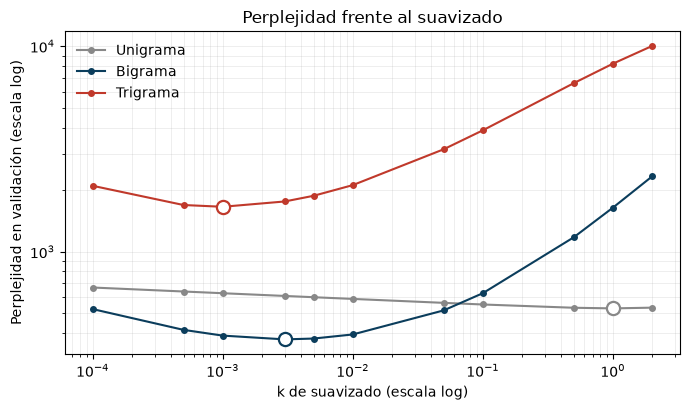

In [66]:
# --- 4.4 Perplejidad frente a k ---
fig, ax = plt.subplots(figsize=(7, 4.2))

for n, nombre, color in [(1, "Unigrama", "#888888"),
                         (2, "Bigrama", "#0b3d5c"),
                         (3, "Trigrama", "#c0392b")]:
    ax.plot(BARRIDO, curvas[n], marker="o", ms=4, color=color, label=nombre)
    ax.scatter([mejor_k[n]], [mejor_ppl[n]], s=90, facecolor="white",
               edgecolor=color, zorder=5, linewidth=1.6)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("k de suavizado (escala log)")
ax.set_ylabel("Perplejidad en validación (escala log)")
ax.set_title("Perplejidad frente al suavizado")
ax.legend(frameon=False)
ax.grid(alpha=0.3, which="both", linewidth=0.5)
fig.tight_layout()
fig.savefig("reporte/img/perplejidad.png", dpi=150)
plt.show()

In [67]:
# --- 4.5 Medición final sobre el conjunto de prueba ---
# Primera y única vez que se toca `test`. El modelo se eligió solo con validación.
n_mejor = min(mejor_ppl, key=mejor_ppl.get)
k_mejor = mejor_k[n_mejor]
print(f"Modelo elegido: n = {n_mejor}, k = {k_mejor}\n")

print(f"{'Modelo':<12}{'k':>9}{'Validación':>14}{'Prueba':>12}")
for n, nombre in [(1, "Unigrama"), (2, "Bigrama"), (3, "Trigrama")]:
    print(f"{nombre:<12}{mejor_k[n]:>9}{mejor_ppl[n]:>14,.1f}"
          f"{perplejidad(modelos[n], test, mejor_k[n]):>12,.1f}")

print(f"\nPerplejidad final del mejor modelo sobre prueba: "
      f"{perplejidad(modelos[n_mejor], test, k_mejor):,.2f}")

Modelo elegido: n = 2, k = 0.003

Modelo              k    Validación      Prueba
Unigrama            1         529.1       550.6
Bigrama         0.003         373.8       397.0
Trigrama        0.001       1,652.1     1,695.0

Perplejidad final del mejor modelo sobre prueba: 397.00


### 4.6 Resultados y discusión

Los tres modelos predicen los mismos 44,723 tokens de validación, así que las perplejidades
son comparables. Con los cuatro valores de k de la sección 3:

| k | Unigrama | Bigrama | Trigrama |
|---|---|---|---|
| 1 (Laplace) | 529.1 | 1,635.3 | 8,210.4 |
| 0.1 | 552.7 | 627.1 | 3,891.2 |
| 0.01 | 588.3 | 395.0 | 2,105.6 |
| 0.001 | 627.1 | 390.0 | 1,652.1 |

Y con el barrido completo, cada modelo en su mejor punto:

| Modelo | mejor k | PPL validación | PPL prueba |
|---|---|---|---|
| Unigrama | 1 | 529.1 | 550.6 |
| **Bigrama** | **0.003** | **373.8** | **397.0** |
| Trigrama | 0.001 | 1,652.1 | 1,695.0 |

Gana el bigrama, y el resultado **sí coincide** con el compromiso entre contexto y dispersión.
El unigrama no tiene contexto y se queda en 529. El bigrama lo aprovecha y baja a 374. El
trigrama, que tendría más contexto todavía, se dispara a 1,652: peor incluso que no usar
contexto. La causa está medida desde la sección 1, en H-12: el 60.2 % de sus trigramas no
aparece en entrenamiento, así que la mayor parte del tiempo no está usando contexto sino
repartiendo la masa que le dejó el suavizado. El punto dulce de este corpus está en n = 2.

Elegido el bigrama con k = 0.003 solo con validación, su perplejidad final sobre prueba es
**397.00**, algo peor que los 373.83 de validación, como era de esperar: validación se usó
para elegir k y prueba no se tocó hasta aquí. Los 23 puntos de diferencia son la parte del
ajuste que no generaliza.

#### ¿Cómo cambia la perplejidad al aumentar k, y por qué?

Sube, y bastante. En el bigrama, pasar de k = 0.003 a k = 1 la multiplica por más de cuatro,
de 373.8 a 1,635.3. La razón es la de la sección 3: con |V| = 20,496, el término k·|V| del
denominador domina el conteo real. Con k = 1 el 90.6 % de la masa después de `don` se va a
palabras que nunca lo siguieron, y el modelo termina dudando entre miles de continuaciones
donde tenía una respuesta clara.

Bajar k tampoco es gratis. Cada curva es una U: el bigrama empeora de 373.8 a 390.0 al pasar
de 0.003 a 0.001, y el unigrama tiene su óptimo en k = 1. Con k demasiado pequeño, los
n-gramas no vistos —y las palabras fuera de vocabulario, el 2.7 % de los tokens— reciben una
probabilidad tan cercana a cero que arrastran la suma de logaritmos. El óptimo se corre a la
izquierda conforme sube n, de 1 a 0.003 y a 0.001, porque cuantos más ceros tiene la tabla más
daño hace repartir masa a ciegas.

## 5. Aplicación práctica: autocompletado

Con el modelo ganador de la sección 4: bigrama con k = 0.003.

In [68]:
# --- 5.1 Autocompletado con el mejor modelo ---
# Con add-k, para un contexto fijo el denominador es constante, así que ordenar por
# probabilidad es ordenar por cuenta: solo hacen falta las continuaciones observadas.
MEJOR, K_MEJOR = modelos[n_mejor], k_mejor


def indice_continuaciones(modelo):
    indice = defaultdict(list)
    for grama, cuenta in modelo.conteo.items():
        indice[grama[:-1]].append((grama[-1], cuenta))
    return indice


continuaciones = indice_continuaciones(MEJOR)


def autocompletar(fragmento, top=5):
    tokens = [t.lower() for t in word_tokenize(separa_signos(fragmento), language="spanish")]
    contexto = tuple(([BOS] * (MEJOR.n - 1) + tokens)[-(MEJOR.n - 1):])
    vistas = sorted(continuaciones[contexto], key=lambda par: (-par[1], par[0]))
    return [(w, MEJOR.prob(contexto, w, K_MEJOR)) for w, _ in vistas[:top]]


for palabra, p in autocompletar("en un lugar de la"):
    print(f"   {palabra:<12} {p:.4f}")

   cabeza       0.0175
   duquesa      0.0171
   mano         0.0166
   mancha       0.0163
   cual         0.0159


In [69]:
# --- 5.2 Seis fragmentos de oraciones reales del conjunto de prueba ---
# Se muestra la palabra que de verdad seguía, para poder juzgar las sugerencias.
FRAGMENTOS = ["luego subió don quijote", "pues , con todo", "- virtud es -",
              "así que , somos ministros", "y , en", "de allí a"]

aciertos = 0
for fragmento in FRAGMENTOS:
    partes = fragmento.split()
    original = next(o for o in test if o[1:1 + len(partes)] == partes)
    real = original[1 + len(partes)]
    sugerencias = autocompletar(fragmento)
    esta = real in [w for w, _ in sugerencias]
    aciertos += esta

    print(f"\n{fragmento!r}  ->  siguiente palabra real: {real!r}"
          f"{'   [en el top-5]' if esta else ''}")
    if len(sugerencias) < 5:
        print(f"    (el modelo solo vio {len(sugerencias)} continuaciones para este contexto)")
    print("    " + ", ".join(f"{w} ({p:.3f})" for w, p in sugerencias))

print(f"\nLa palabra real aparece en el top-5 en {aciertos} de {len(FRAGMENTOS)} fragmentos.")


'luego subió don quijote'  ->  siguiente palabra real: 'sobre'
    - (0.251), , (0.236), de (0.073), . (0.051), y (0.043)

'pues , con todo'  ->  siguiente palabra real: 'eso'   [en el top-5]
    lo (0.155), el (0.116), esto (0.099), eso (0.074), , (0.064)

'- virtud es -'  ->  siguiente palabra real: 'respondió'   [en el top-5]
    , (0.150), dijo (0.123), respondió (0.115), no (0.040), ¡ (0.036)

'así que , somos ministros'  ->  siguiente palabra real: 'de'   [en el top-5]
    (el modelo solo vio 3 continuaciones para este contexto)
    de (0.044), , (0.030), infernales (0.015)

'y , en'  ->  siguiente palabra real: 'diciendo'
    el (0.116), la (0.114), su (0.039), las (0.032), los (0.026)

'de allí a'  ->  siguiente palabra real: 'poco'
    la (0.093), su (0.054), los (0.046), lo (0.036), don (0.028)

La palabra real aparece en el top-5 en 3 de 6 fragmentos.


In [70]:
# --- 5.3 Generación de oraciones con los tres modelos ---
# No lo pide la sección 5, pero la 6 pregunta por la generación de texto (decisión D-05).
# Se muestrea de las continuaciones observadas, sin suavizar: el suavizado solo aportaría
# ruido del vocabulario entero.
indices = {n: indice_continuaciones(modelos[n]) for n in (1, 2, 3)}


def generar(n, semilla, maximo=40):
    azar = random.Random(semilla)
    contexto = tuple([BOS] * (n - 1))
    salida = []
    for _ in range(maximo):
        opciones = indices[n][contexto]
        if not opciones:
            break
        palabras, pesos = zip(*opciones)
        palabra = azar.choices(palabras, weights=pesos, k=1)[0]
        if palabra == EOS:
            break
        salida.append(palabra)
        contexto = (contexto + (palabra,))[-(n - 1):] if n > 1 else ()
    return " ".join(salida)


for n, nombre in [(1, "Unigrama"), (2, "Bigrama"), (3, "Trigrama")]:
    print(f"\n{nombre}")
    for semilla in (1, 2):
        print(f"   {generar(n, semilla)}")


Unigrama
   , pelo venir no el o `` discurso de y perdone más otras y tan tiene en posada place y y por pícaro della , la y en si el en en , dijo
   inmundicia dorada que que segunda has dios - pero valor quijote , suerte triste está terrestre cargado por tan . y y : pues me feo los se en y con , adelante desmandó un , visitar oyólo oh amador

Bigrama
   - señor de los cielos , ni zarzo .
   muévate , y , empinándola , sin saber y uno en esto y por ahora sólo procure su madre , y aun las detenga , sintió tanto ahínco y aun los que la bandera desta manera vamos subiendo sobre quien

Trigrama
   - par dios que así acomete mi señor , nos deshizo este pensamiento guió a rocinante , si muero , pero , llegando a él y hártate , que ni sabía quién era y qué le desnudaba .
   muévate , socarrón y malintencionado de malambruno ; que si fuera trapo mal lavado , y aquí hablé dél ; y , cuando se lo prometió y ella me puse en este tiempo veas lo que otro no pudiera negar


In [71]:
# --- 5.4 ¿Cuánto del texto generado es copia literal del entrenamiento? ---
corpus_train = " ".join(" ".join(o[1:-1]) for o in train)


def racha_literal(texto):
    """Secuencia de palabras más larga del texto que aparece tal cual en entrenamiento."""
    palabras = texto.split()
    mejor, frase = 0, ""
    for i in range(len(palabras)):
        for j in range(i + mejor + 1, len(palabras) + 1):
            trozo = " ".join(palabras[i:j])
            if trozo not in corpus_train:
                break
            mejor, frase = j - i, trozo
    return mejor, frase


print(f"{'Modelo':<12}{'racha literal más larga (3 muestras)':>40}")
for n, nombre in [(1, "Unigrama"), (2, "Bigrama"), (3, "Trigrama")]:
    rachas = [racha_literal(generar(n, s)) for s in (1, 2, 3)]
    print(f"\n{nombre:<12}{str([m for m, _ in rachas]):>40}")
    print(f"    la más larga: {max(rachas)[1]!r}")

Modelo          racha literal más larga (3 muestras)

Unigrama                                   [3, 3, 3]
    la más larga: 'tan . y'

Bigrama                                    [4, 4, 5]
    la más larga: '- dijo sancho panza .'

Trigrama                                   [5, 7, 7]
    la más larga: 'vuestra merced tan duro de celebro ,'


### 5.5 Resultados y discusión

Sobre seis fragmentos de oraciones reales de prueba, la palabra que de verdad seguía aparece
en el top-5 en **tres de los seis**:

| Fragmento | Real | Top-5 |
|---|---|---|
| `pues , con todo` | `eso` | lo, el, esto, **eso**, `,` |
| `- virtud es -` | `respondió` | `,`, dijo, **respondió**, no, ¡ |
| `así que , somos ministros` | `de` | **de**, `,`, infernales |
| `luego subió don quijote` | `sobre` | `-`, `,`, de, `.`, y |
| `y , en` | `diciendo` | el, la, su, las, los |
| `de allí a` | `poco` | la, su, los, lo, don |

Los tres fallos no son absurdos: después de `en` el modelo propone artículos, que es lo que
sigue casi siempre, solo que aquí venía un gerundio. Con una sola palabra de contexto no hay
manera de saberlo, y eso es el techo del bigrama, no un error. Se ve mejor todavía con
`en un lugar de la`: el modelo solo mira `la` y sugiere `cabeza, duquesa, mano, mancha`, con
la palabra correcta en cuarto lugar y por casualidad. La frase más famosa del español no le
sirve de nada porque no la puede ver.

Se nota también el peso de la puntuación (D-14): la coma y la raya entran al top-5 en varios
fragmentos. Para un autocompletado real convendría filtrarlas; como modelo de lenguaje son
predicciones legítimas. Y en `somos ministros` el modelo solo vio **tres** continuaciones y no
puede ofrecer cinco: la dispersión de la sección 1 apareciendo en la aplicación.

#### El vocabulario y el estilo del siglo XVII

Se nota en todo. Lo más probable después de `quijote` es la **raya de diálogo** (0.251),
porque el libro es casi todo conversación con la convención tipográfica de la época. Salen
`vuesa merced`, `dél`, `desta`, `socarrón`, `malambruno`, y fórmulas enteras como
`- dijo sancho panza .`. Un autocompletado entrenado con esto sería inservible para escribir
español actual: predice muy bien el de Cervantes, que es lo que se le pidió.

#### Generación: el trigrama escribe mejor y puntúa peor

El unigrama produce `, pelo venir no el o discurso de y perdone más otras`, palabras sueltas
sin sintaxis. El bigrama arma tramos legibles pero se pierde. El trigrama llega a
`- par dios que así acomete mi señor , nos deshizo este pensamiento` o
`socarrón y malintencionado de malambruno`, que pasan por Cervantes.

Contradice la sección 4, donde el trigrama era el peor con 1,652 de perplejidad. Midiendo la
secuencia literal más larga que cada texto generado comparte con entrenamiento, el unigrama
llega a 3 palabras, el bigrama a 5 y el trigrama a **7** (`vuestra merced tan duro de celebro
,`). El trigrama no escribe mejor español: **está recitando trozos del libro**. Al generar
solo elige entre continuaciones que sí vio, así que la dispersión no le estorba; al evaluar
texto nuevo, esa misma dispersión lo hunde. Que un texto suene bien no significa que el modelo
generalice.